In [1]:
# | Relation                        | Type IDs   |
# | ------------------------------- | ---------- |
# | บุคคลเดียวกัน (Same Person)        | 1, 2, 5, 7 |
# | บุคคลต่างกัน (Different Person)    | 3, 4, 6, 8 |

# ไฟล์ชุด base (ก่อน unlearning) = calculated_distances_effnet_base_8type.csv
# ไฟล์ชุด unlearning (หลัง unlearning) = type8_combined_calculated_distances.csv

# 🎯 สิ่งที่ต้องการสร้าง (4 ตัวแปร)

# same_after
# ระยะห่างของ “บุคคลเดียวกัน” หลังทำ unlearning
# → จากไฟล์ unlearning (EffNet หลัง unlearn)

# same_before
# ระยะห่างของ “บุคคลเดียวกัน” ก่อนทำ unlearning
# → จากไฟล์ base (EffNet ปกติ)

# diff_after
# ระยะห่างของ “บุคคลต่างกัน” หลังทำ unlearning

# diff_before
# ระยะห่างของ “บุคคลต่างกัน” ก่อนทำ unlearning

In [2]:
import pandas as pd

# -----------------------------------------
# โหลดไฟล์ CSV ทั้ง 2 แบบ
# -----------------------------------------
base_file = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/calculated_distances_effnet_base_8type.csv"
unlearn_file0 = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/type8_combined_calculated_distances.csv"
unlearn_file1 ="/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/combined_calculated_distances.csv"
df_before = pd.read_csv(base_file)       # EffNet ธรรมดา (before unlearning)
df_after0 = pd.read_csv(unlearn_file0)     # EffNet unlearned (after unlearning)
df_after1 = pd.read_csv(unlearn_file1) 
df_after = df_after0.append(df_after1)

# -----------------------------------------
# กำหนด Type ID แบ่งเป็น same/diff
# -----------------------------------------
# same_types = [1, 2, 5, 7]
same_types = [ 5]
# diff_types = [3, 4, 6, 8]

In [3]:
# df_after_diff_types = df_after[df_after["type"].isin(diff_types)]

# df_before_diff_types = df_before[df_before["type"].isin(diff_types)]


# # เลือกเฉพาะคอลัมน์ที่ต้องใช้
# before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
#     columns={'distance': 'distance_before'}
# )

# after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
#     columns={'distance': 'distance_after'}
# )

# # เชื่อมด้วย 'path_img1', path_img2
# df_merged_diff_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

# df_merged_diff_types

In [4]:
df_after_same_types = df_after[df_after["type"].isin(same_types)]

df_before_same_types = df_before[df_before["type"].isin(same_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_same_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

df_merged_same_types

,path_img1,path_img2,distance_after,distance_before
0,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,0.884530,0.679878
1,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.165408,0.669130
2,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,0.887516,0.180091
3,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,0.870589,0.552067
4,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.110632,0.317966
...,...,...,...,...
8334,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.081425,0.654445
8335,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.312852,0.181266
8336,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.034695,0.755229
8337,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.013104,0.477147


In [5]:
# -----------------------------------------
# 1) บุคคลเดียวกัน AFTER (unlearning)
# -----------------------------------------
same_after = df_merged_same_types["distance_after"].values

# 2) บุคคลเดียวกัน BEFORE (ธรรมดา)
# -----------------------------------------
same_before = df_merged_same_types["distance_before"].values

# -----------------------------------------
# 3) บุคคลต่างกัน AFTER (unlearning)
# -----------------------------------------
# diff_after = df_merged_diff_types["distance_after"].values

# -----------------------------------------
# 4) บุคคลต่างกัน BEFORE (ธรรมดา)
# -----------------------------------------
# diff_before = df_merged_diff_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
print("same_before:", len(same_before))
print("same_after :", len(same_after))
# print("diff_before:", len(diff_before))
# print("diff_after :", len(diff_after))

same_before: 8339
same_after : 8339


# ทอสอบคนเดียวกัน

In [6]:
# คำถาม - ระยะห่างหลัง unlearning ลดลงหรือไม่?
# เราจะใช้ One-tailed paired t-test (H₁: after < before)

In [7]:
# (distance_after[i], distance_before[i])
# คือระยะห่าง “ก่อน” และ “หลัง” ของภาพคู่เดียวกัน
# ซึ่งเหมาะสมที่สุดสำหรับ paired t-test, Wilcoxon/Mann-Whitney, KS-test, effect size

In [8]:
# 📌 สรุปผลแบบเข้มงวดต้องดู 5 อย่าง

# Normality Test → เพื่อเลือก parametric / non-parametric

# t-test (one-sided) → ตรวจค่าเฉลี่ยลดลงหรือไม่

# Mann–Whitney U → robust test ไม่ต้องพึ่ง normal

# KS-test → ตรวจกระจายลดลงจริงหรือไม่

# Effect Size (Cohen’s d / Cliff’s delta) → ผลลดลง “แรงแค่ไหน”

## 1) ✅ Normality Test (Shapiro–Wilk)

ทดสอบว่า distribution เป็น normal หรือไม่ 

In [9]:
import numpy as np
from scipy.stats import shapiro, ttest_rel

print("Shapiro Test – Same Before:", shapiro(same_before))
print("Shapiro Test – Same After :", shapiro(same_after)) 
# ถ้า p < 0.05 → ไม่เป็น normal → จำเป็นต้องใช้ non-parametric test 

Shapiro Test – Same Before: ShapiroResult(statistic=0.923431396484375, pvalue=0.0)
Shapiro Test – Same After : ShapiroResult(statistic=0.9712522625923157, pvalue=7.914881809045105e-38)


/home/yupaporn/miniconda3/envs/USAI3/lib/python3.6/site-packages/scipy/stats/morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


##  2) 🎯 Independent One-Tailed t-test (parametric)

(ทดสอบ H1: mean_after < mean_before)

In [10]:
t_stat, p_two = ttest_rel(same_after, same_before)

p_one = p_two / 2   # one-tailed

print("t-statistic:", t_stat)
print("p-value (one-tailed):", p_one)

if p_one < 0.05 and t_stat < 0:
    print("Reject H0 → ระยะห่างลดลงอย่างมีนัยสำคัญ")
else:
    print("Fail to Reject H0 → ยังไม่พบหลักฐานว่าระยะห่างลดลง")


t-statistic: 144.80196735295218
p-value (one-tailed): 0.0
Fail to Reject H0 → ยังไม่พบหลักฐานว่าระยะห่างลดลง


In [11]:
import numpy as np
from scipy.stats import wilcoxon, ks_2samp

alpha = 0.05  # ระดับนัยสำคัญที่ใช้ตัดสิน

# ---------------------------------
# 0) สรุปค่าเฉลี่ย / ส่วนเบี่ยงเบน
# ---------------------------------
def describe(arr, name):
    print(f"=== {name} ===")
    print(f"n        = {len(arr)}")
    print(f"mean     = {np.mean(arr):.6f}")
    print(f"median   = {np.median(arr):.6f}")
    print(f"std      = {np.std(arr, ddof=1):.6f}")
    print(f"min/max  = {np.min(arr):.6f} / {np.max(arr):.6f}")
    print()

describe(same_before, "Same Person - BEFORE unlearning")
describe(same_after,  "Same Person - AFTER  unlearning")

=== Same Person - BEFORE unlearning ===
n        = 8339
mean     = 0.476279
median   = 0.391350
std      = 0.336925
min/max  = 0.006726 / 1.515839

=== Same Person - AFTER  unlearning ===
n        = 8339
mean     = 1.132939
median   = 1.169535
std      = 0.291019
min/max  = 0.224792 / 1.726139



## 1) Wilcoxon Signed-Rank Test (paired, one-tailed)

In [12]:
# --------------------------------------------------
# 1) Wilcoxon Signed-Rank Test (paired, one-tailed)
#    H0 : median_after >= median_before
#    H1 : median_after <  median_before   (ระยะห่าง "ลดลง")
# --------------------------------------------------
w_stat, p_wilcox = wilcoxon(same_after, same_before, alternative='less')
print("===== Wilcoxon Signed-Rank Test (one-tailed) =====")
print("W statistic:", w_stat)
print("p-value    :", p_wilcox)

if p_wilcox < alpha:
    print("Reject H0  → ระยะห่างหลัง unlearning ลดลงอย่างมีนัยสำคัญ (เชิง median)")
else:
    print("Fail to Reject H0 → ยังไม่พบหลักฐานว่าระยะห่างหลัง unlearning ลดลง")
print()

===== Wilcoxon Signed-Rank Test (one-tailed) =====
W statistic: 34088881.0
p-value    : 1.0
Fail to Reject H0 → ยังไม่พบหลักฐานว่าระยะห่างหลัง unlearning ลดลง



## 2) Kolmogorov–Smirnov Test (KS) – distribution shift

In [13]:
# --------------------------------------------------
# 2) Kolmogorov–Smirnov Test (KS) – distribution shift
#    H0 : distribution_after >= distribution_before โดยรวม
#    H1 : distribution_after <  distribution_before  (ค่า after เลื่อนไปทางซ้าย)
# --------------------------------------------------
ks_stat, p_ks = ks_2samp(same_after, same_before, alternative='less')
print("===== KS Test (two-sample, one-tailed) =====")
print("KS statistic:", ks_stat)
print("p-value     :", p_ks)

if p_ks < alpha:
    print("Reject H0  → distribution หลัง unlearning เลื่อนไปทางค่าที่ต่ำกว่าอย่างมีนัยสำคัญ")
else:
    print("Fail to Reject H0 → ยังไม่พบหลักฐานว่า distribution หลัง unlearning ลดลง")
print()


===== KS Test (two-sample, one-tailed) =====
KS statistic: 0.6745413119079027
p-value     : 0.0
Reject H0  → distribution หลัง unlearning เลื่อนไปทางค่าที่ต่ำกว่าอย่างมีนัยสำคัญ



## 3) Effect Size
##    3.1 Cohen's d (สำหรับ paired → ใช้ diff)

In [14]:
# --------------------------------------------------
# 3) Effect Size
#    3.1 Cohen's d (สำหรับ paired → ใช้ diff)
# --------------------------------------------------
diff = same_after - same_before   # ถ้าค่าเฉลี่ย diff < 0 = ระยะห่างลดลง
mean_diff = np.mean(diff)
sd_diff   = np.std(diff, ddof=1)
cohens_d  = mean_diff / sd_diff

print("===== Effect Size =====")
print(f"Mean difference (after - before) = {mean_diff:.6f}")
print(f"SD of difference                 = {sd_diff:.6f}")
print(f"Cohen's d (paired)               = {cohens_d:.4f}")

# แปล Cohen's d แบบคร่าว ๆ
if abs(cohens_d) < 0.2:
    magnitude = "very small"
elif abs(cohens_d) < 0.5:
    magnitude = "small"
elif abs(cohens_d) < 0.8:
    magnitude = "medium"
else:
    magnitude = "large"
print("Magnitude (Cohen's d):", magnitude)
print()

===== Effect Size =====
Mean difference (after - before) = 0.656660
SD of difference                 = 0.414117
Cohen's d (paired)               = 1.5857
Magnitude (Cohen's d): large



## 3.2 Cliff's Delta (non-parametric effect size)

In [15]:

# --------------------------------------------------
#    3.2 Cliff's Delta (non-parametric effect size)
# --------------------------------------------------
def cliffs_delta(a, b):
    m, n = len(a), len(b)
    more = 0
    less = 0
    for x in a:
        more += np.sum(x > b)
        less += np.sum(x < b)
    return (more - less) / (m * n)

delta = cliffs_delta(same_after, same_before)
print("Cliff's Delta:", delta)

# แปลขนาด Cliff's delta
abs_delta = abs(delta)
if abs_delta < 0.11:
    mag = "negligible"
elif abs_delta < 0.28:
    mag = "small"
elif abs_delta < 0.43:
    mag = "medium"
else:
    mag = "large"
print("Magnitude (Cliff's delta):", mag)

Cliff's Delta: 0.8278683817944198
Magnitude (Cliff's delta): large


## 📊 Visualization (Distribution & Boxplot)

ช่วยดูภาพรวมว่าหลังโดน unlearning ลดลงไหม

### Histogram + KDE

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

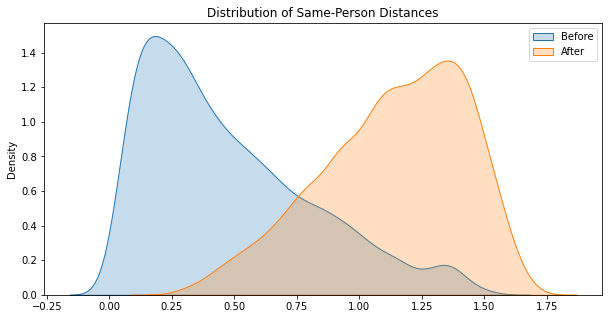

In [17]:
plt.figure(figsize=(10,5))
sns.kdeplot(same_before, label='Before', shade=True)
sns.kdeplot(same_after, label='After', shade=True)
plt.title("Distribution of Same-Person Distances")
plt.legend()
plt.show()


### Boxplot comparison

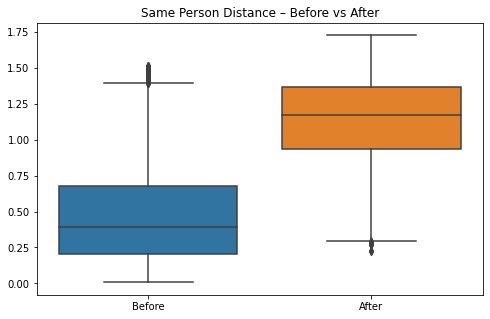

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[same_before, same_after])
plt.xticks([0,1], ['Before', 'After'])
plt.title("Same Person Distance – Before vs After")
plt.show()
